## Anomaly Detection with Isolation Forest and FastAPI

This notebook demonstrates how to train a simple anomaly detection model (Isolation Forest) on synthetic heart rate data and then expose it via a REST API using FastAPI.

In [1]:
# Install necessary libraries
!pip install pandas scikit-learn fastapi uvicorn nest_asyncio pyngrok

### 1. Generate Synthetic Heart Rate Data

We'll create some sample heart rate data, including some anomalous high and low values.

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic normal heart rate data
np.random.seed(42)
normal_hr = np.random.normal(loc=70, scale=5, size=1000)

# Introduce some anomalies
anomaly_high = np.random.normal(loc=120, scale=10, size=20) # High heart rate
anomaly_low = np.random.normal(loc=40, scale=5, size=10)   # Low heart rate

# Combine data
heart_rate_data = np.concatenate([normal_hr, anomaly_high, anomaly_low])

df = pd.DataFrame({'heart_rate': heart_rate_data})

print("Generated heart rate data with {} samples.".format(len(df)))
display(df.head())

Generated heart rate data with 1030 samples.


,heart_rate
0,72.483571
1,69.308678
2,73.238443
3,77.615149
4,68.829233


### 2. Visualize the Data

Let's visualize the generated data to see the distribution and the introduced anomalies.

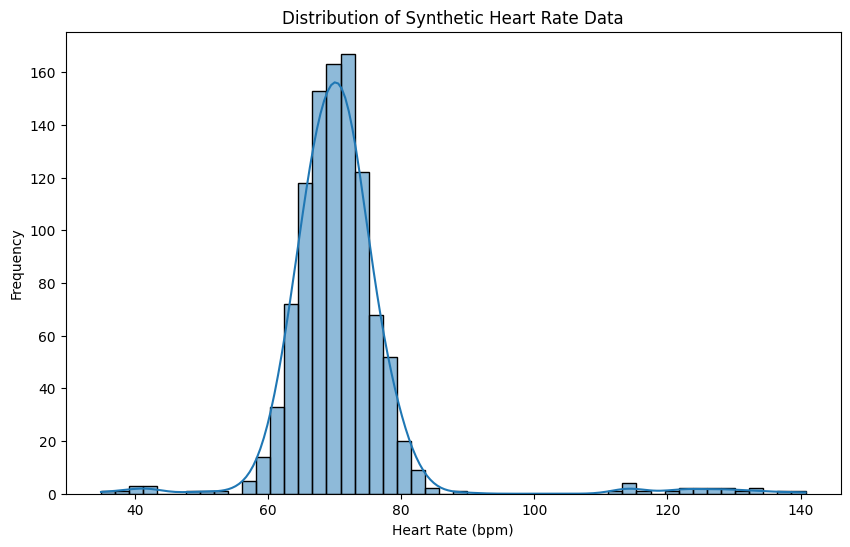

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['heart_rate'], bins=50, kde=True)
plt.title('Distribution of Synthetic Heart Rate Data')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

### 3. Train the Anomaly Detection Model (Isolation Forest)

We will use `IsolationForest` from `scikit-learn` to train a model that can identify outliers.

In [4]:
# Initialize and train the Isolation Forest model
# contamination is the proportion of outliers in the data set
model = IsolationForest(contamination=0.03, random_state=42)
model.fit(df[['heart_rate']])

# Predict anomalies (-1 for outliers, 1 for inliers)
df['anomaly'] = model.predict(df[['heart_rate']])

# Filter out anomalies
anomalies = df[df['anomaly'] == -1]

print(f"Number of detected anomalies: {len(anomalies)}")
display(anomalies.head())

Number of detected anomalies: 31


,heart_rate,anomaly
262,53.793663,-1
1000,133.993554,-1
1001,129.246337,-1
1002,120.596304,-1
1003,113.530632,-1


### 4. Visualize Detected Anomalies

Let's plot the heart rate data and highlight the detected anomalies.

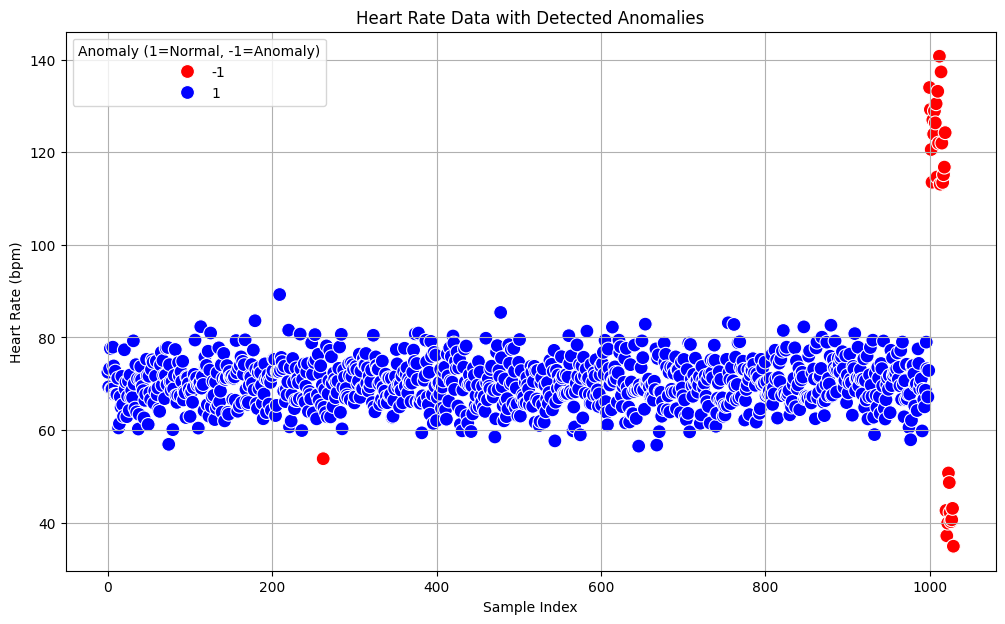

In [5]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x=df.index, y='heart_rate', hue='anomaly', data=df, palette={1: 'blue', -1: 'red'}, markers={1: 'o', -1: 'X'}, s=100)
plt.title('Heart Rate Data with Detected Anomalies')
plt.xlabel('Sample Index')
plt.ylabel('Heart Rate (bpm)')
plt.legend(title='Anomaly (1=Normal, -1=Anomaly)')
plt.grid(True)
plt.show()

### 5. Expose the Model via a REST API (FastAPI)

Now, we'll create a simple FastAPI application to serve our trained model. We'll use `nest_asyncio` and `pyngrok` to run the API directly within Colab and expose it to the internet.

In [7]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import uvicorn
import nest_asyncio
from pyngrok import ngrok
import threading
import asyncio
from google.colab import userdata

# Apply nest_asyncio to allow uvicorn to run in Colab's event loop
nest_asyncio.apply()

app = FastAPI()

# Define the request body schema
class HeartRateInput(BaseModel):
    heart_rate: float

@app.get("/heart_rate_anomaly")
async def get_root():
    return {"message": "Heart Rate Anomaly Detection API. Use /predict to check heart rate."}

@app.post("/predict")
async def predict_anomaly(data: HeartRateInput):
    hr_value = data.heart_rate

    if not (20 <= hr_value <= 250): # Basic sanity check for heart rate
        raise HTTPException(status_code=400, detail="Heart rate value out of realistic range (20-250 bpm).")

    # Make prediction using the trained model
    prediction = model.predict(np.array([[hr_value]]))[0]

    is_anomaly = True if prediction == -1 else False
    return {"heart_rate": hr_value, "is_anomaly": is_anomaly, "prediction_score": model.decision_function(np.array([[hr_value]]))[0]}

# Function to run uvicorn in a separate thread
def run_api():
    # Use asyncio.run to manage the event loop for uvicorn
    try:
        asyncio.run(uvicorn.Server(uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="warning")).serve())
    except Exception as e:
        print(f"Uvicorn server stopped with error: {e}")

# Start the FastAPI server in a new thread
api_thread = threading.Thread(target=run_api)
api_thread.start()

# Setup ngrok to expose the local server to the internet
print("Fetching ngrok authentication token from Colab secrets...")
# Make sure to add your ngrok auth token to Colab Secrets, named 'NGROK_AUTH_TOKEN'
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("Setting up ngrok tunnel...")
public_url = ngrok.connect(8000)
print(f"FastAPI running on: {public_url}")
print("You can test the API by visiting the URL above in your browser or using tools like curl/Postman.")
print("Example GET: {public_url}/heart_rate_anomaly")
print("Example POST (with 'your_public_url'):")
print("```bash")
print("curl -X POST \\\n  '{public_url}/predict' \\\n  -H 'Content-Type: application/json' \\\n  -d '{\"heart_rate\": 130}'")
print("```")


Fetching ngrok authentication token from Colab secrets...


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use


SecretNotFoundError: Secret NGROK_AUTH_TOKEN does not exist.

### How to stop the API

To stop the ngrok tunnel and the FastAPI server, you would typically restart the Colab runtime or explicitly kill the ngrok process. For now, it will remain active until the Colab session ends or you manually intervene.